In [2]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, print_metrics, plot_regression_results, evaluate_minirocket_vitaldb, train_mlp, select_top_pearson_features

In [4]:
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=1000,
    STEP_SIZE=1000
)

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_0overlap/vitaldb_checkpoints"

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [01:21<00:00, 117.41it/s]


Skipped recordings: 107


100%|██████████| 1200/1200 [00:10<00:00, 112.73it/s]


Skipped recordings: 8


100%|██████████| 1200/1200 [00:10<00:00, 113.53it/s]


Skipped recordings: 9


In [5]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (263103, 1, 1000)
y_train: (263103, 2)
X_val: (33223, 1, 1000)
y_val: (33223, 2)
X_test: (33347, 1, 1000)
y_test: (33347, 2)


In [6]:
from sktime.transformations.panel.rocket import MiniRocket

rocket = MiniRocket(num_kernels=5000, random_state=42)

rocket.fit(X_train)

MiniRocket(num_kernels=5000, random_state=42)

In [7]:
def transform_to_disk(rocket, X, path, bs=2000):
    d = rocket.transform(X[:2]).shape[1]
    out = np.lib.format.open_memmap(path, mode="w+", dtype=np.float32, shape=(len(X), d))
    for i in tqdm(range(0, len(X), bs)):
        out[i:i+bs] = rocket.transform(X[i:i+bs]).to_numpy(dtype=np.float32)
    out.flush()
    return out

transform_to_disk(rocket, X_train, "X_train_minirocket.npy")
transform_to_disk(rocket, X_val,   "X_val_minirocket.npy")
transform_to_disk(rocket, X_test,  "X_test_minirocket.npy")
del X_train, X_val, X_test; import gc; gc.collect()   # raw windows no longer needed

100%|██████████| 17/17 [00:21<00:00,  1.28s/it]


1993

In [8]:
X_train_rocket = np.load("X_train_minirocket.npy", mmap_mode="r")
X_val_rocket   = np.load("X_val_minirocket.npy",   mmap_mode="r")
X_test_rocket  = np.load("X_test_minirocket.npy",  mmap_mode="r")

In [9]:
y_train_sbp = y_train[:, 0]
y_train_dbp = y_train[:, 1]

y_val_sbp = y_val[:, 0]
y_val_dbp = y_val[:, 1]

y_test_sbp = y_test[:, 0]
y_test_dbp = y_test[:, 1]

## RIDGE REGRESSION ##

In [10]:
class RidgeModel:
    def __init__(s, mu, sd, W, ym, col): s.mu, s.sd, s.W, s.ym, s.col = mu, sd, W, ym, col
    def predict(s, X):
        X = np.asarray(X, dtype=np.float32)
        return ((X - s.mu) / s.sd) @ s.W[:, s.col] + s.ym[s.col]

def ridge_stats(X, Y, bs=5000):
    n, d = X.shape
    XtX = np.zeros((d, d)); Xty = np.zeros((d, Y.shape[1]))
    sx = np.zeros(d); sy = np.zeros(Y.shape[1])
    for i in tqdm(range(0, n, bs)):
        xb = np.asarray(X[i:i+bs], dtype=np.float64); yb = Y[i:i+bs].astype(np.float64)
        XtX += xb.T @ xb; Xty += xb.T @ yb; sx += xb.sum(0); sy += yb.sum(0)
    return XtX, Xty, sx, sy, n

def solve_ridge(stats, alpha):
    XtX, Xty, sx, sy, n = stats
    mu, ym = sx / n, sy / n
    C = XtX - n * np.outer(mu, mu)
    sd = np.sqrt(np.diag(C) / n); sd[sd == 0] = 1
    C = C / np.outer(sd, sd)
    c = (Xty - n * np.outer(mu, ym)) / sd[:, None]
    W = np.linalg.solve(C + alpha * np.eye(len(mu)), c)
    return mu.astype(np.float32), sd.astype(np.float32), W.astype(np.float32), ym.astype(np.float32)

stats = ridge_stats(X_train_rocket, y_train)

best = {}
for col, name in [(0, "SBP"), (1, "DBP")]:
    scores = {}
    for a in [0.01, 0.1, 1, 10, 100, 1000, 10000]:
        mu, sd, W, ym = solve_ridge(stats, a)
        m = RidgeModel(mu, sd, W, ym, col)
        pred = np.concatenate([m.predict(X_val_rocket[i:i+5000]) for i in range(0, len(X_val_rocket), 5000)])
        scores[a] = np.sqrt(np.mean((pred - y_val[:, col])**2))
    a_best = min(scores, key=scores.get)
    print(name, "best alpha:", a_best, "val RMSE:", scores[a_best])
    best[name] = RidgeModel(*solve_ridge(stats, a_best), col)

grid_ridge_sbp, grid_ridge_dbp = best["SBP"], best["DBP"]

100%|██████████| 53/53 [00:21<00:00,  2.42it/s]


SBP best alpha: 1000 val RMSE: 16.964748
DBP best alpha: 10000 val RMSE: 8.857731


In [11]:
def batch_predict(m, X, bs=5000):
    return np.concatenate([m.predict(X[i:i+bs]) for i in range(0, len(X), bs)])

y_pred_sbp = batch_predict(grid_ridge_sbp, X_test_rocket)
y_pred_dbp = batch_predict(grid_ridge_dbp, X_test_rocket)

In [12]:
print("MiniRocket + Ridge — SBP")
print("------------------------")
print_metrics(y_test_sbp, y_pred_sbp)

print("\nMiniRocket + Ridge — DBP")
print("------------------------")
print_metrics(y_test_dbp, y_pred_dbp)

MiniRocket + Ridge — SBP
------------------------
RMSE: 17.5420
MSE : 307.7228
R²  : 0.4174
MAE : 13.3417

MiniRocket + Ridge — DBP
------------------------
RMSE: 9.0066
MSE : 81.1193
R²  : 0.3506
MAE : 6.6308


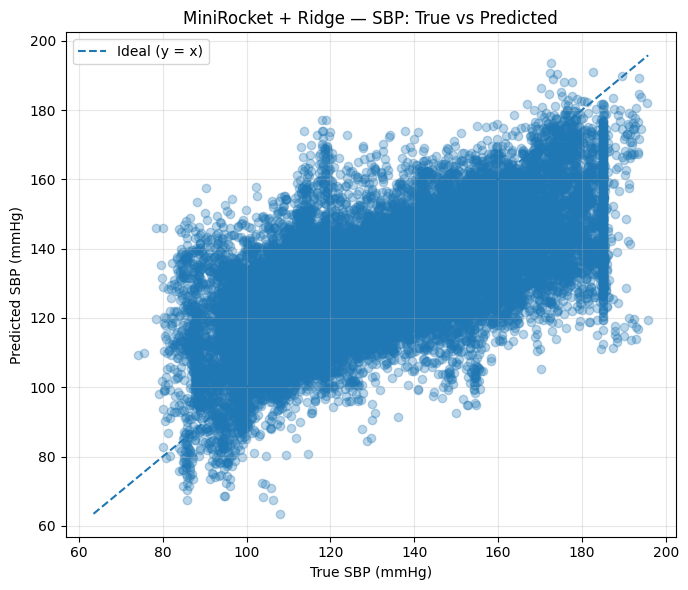

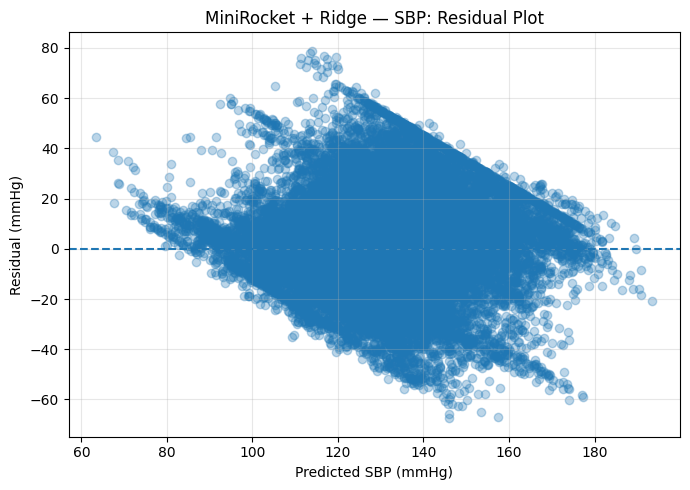

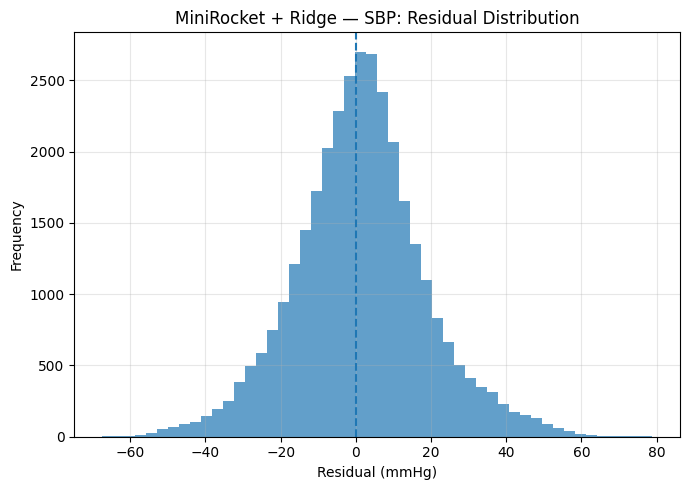

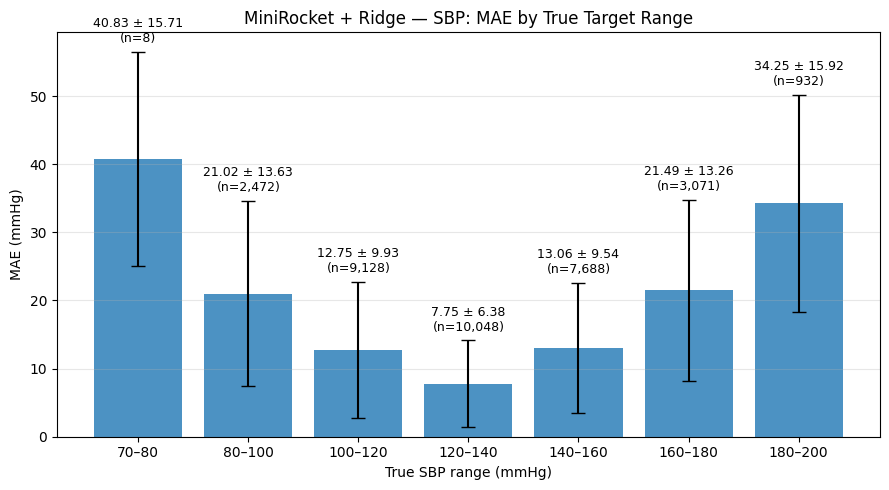

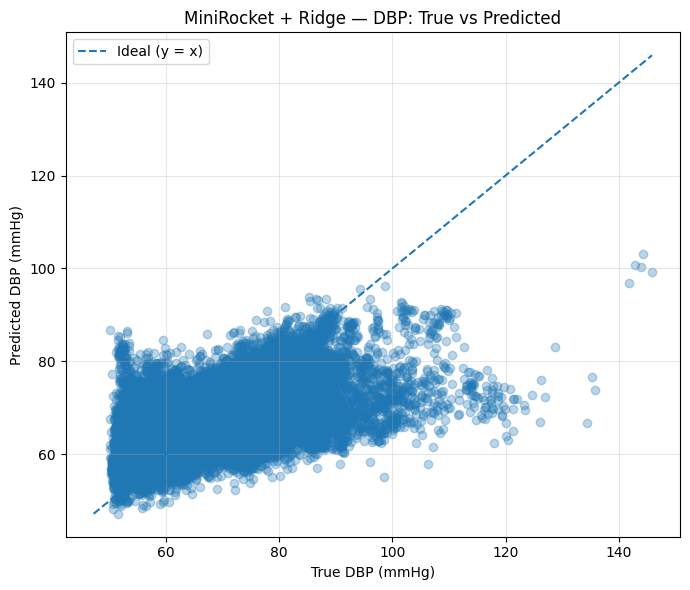

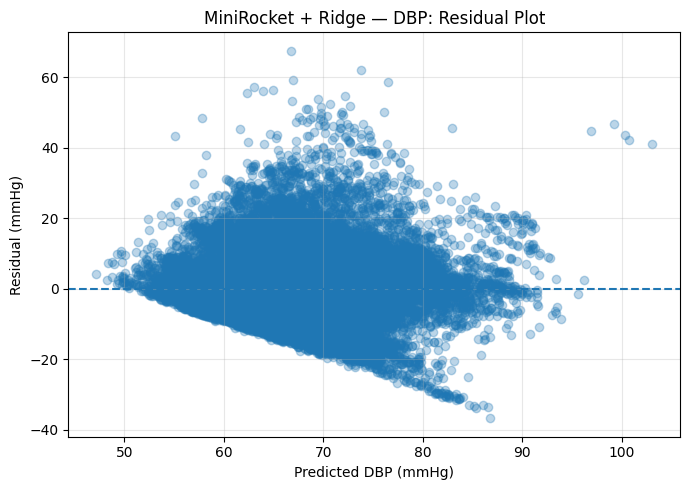

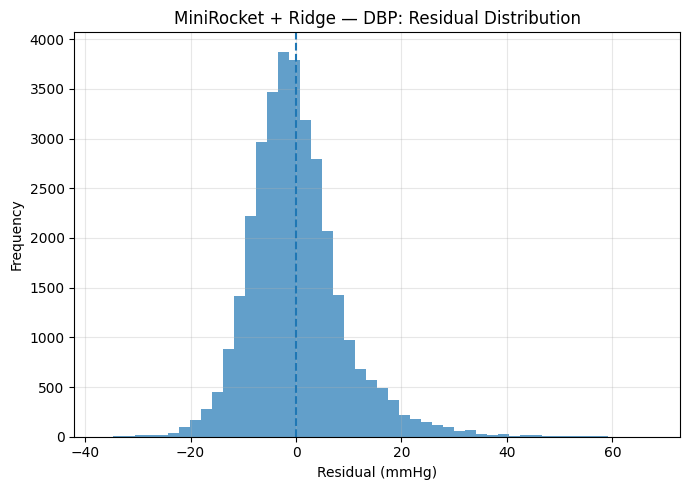

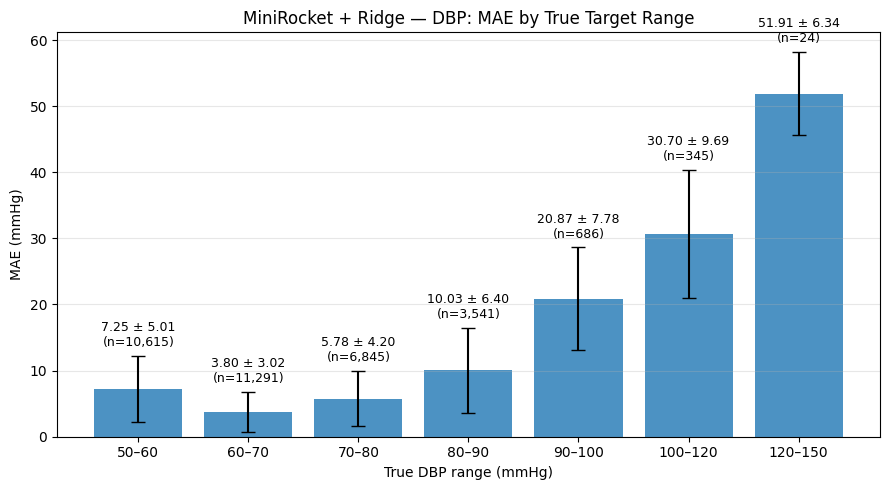

In [13]:
plot_regression_results(
    y_test_sbp,
    y_pred_sbp,
    "MiniRocket + Ridge",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_dbp,
    "MiniRocket + Ridge",
    "DBP"
)

Number of VitalDB cases: 1968


MiniROCKET VitalDB prediction: 100%|██████████| 1968/1968 [36:26<00:00,  1.11s/case] 




MiniROCKET + Ridge
VITALDB ZERO-SHOT RESULTS

SBP
------------------------------
RMSE: 25.3215
MSE : 641.1767
R²  : -0.5051
MAE : 19.5715

DBP
------------------------------
RMSE: 14.6253
MSE : 213.8986
R²  : -0.3215
MAE : 11.2297


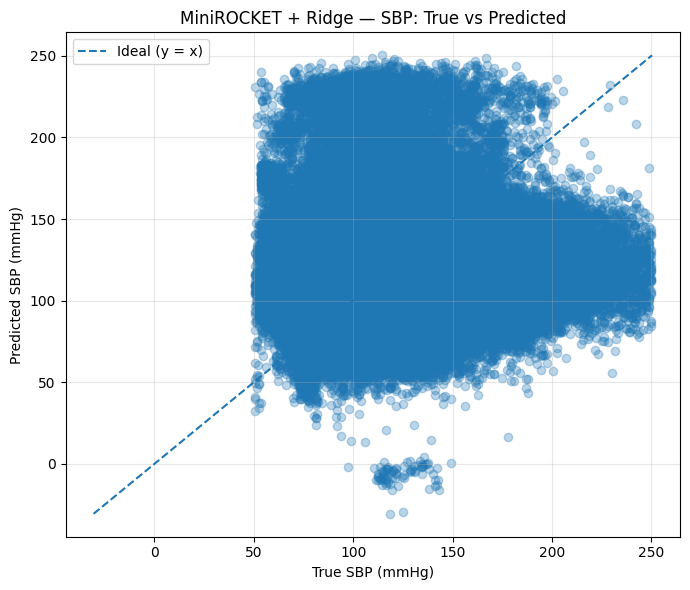

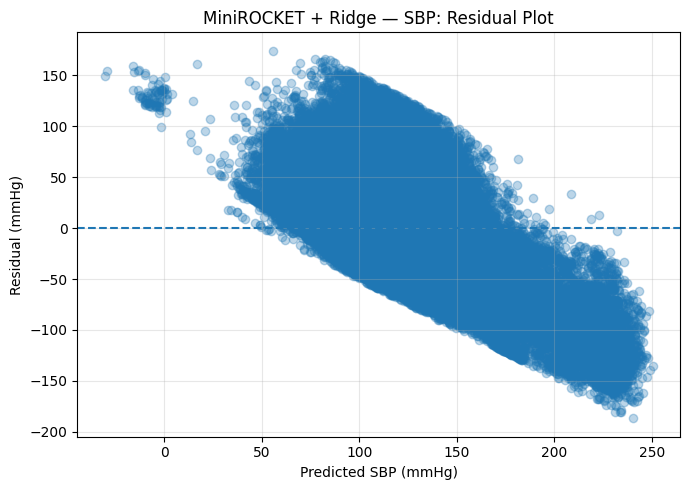

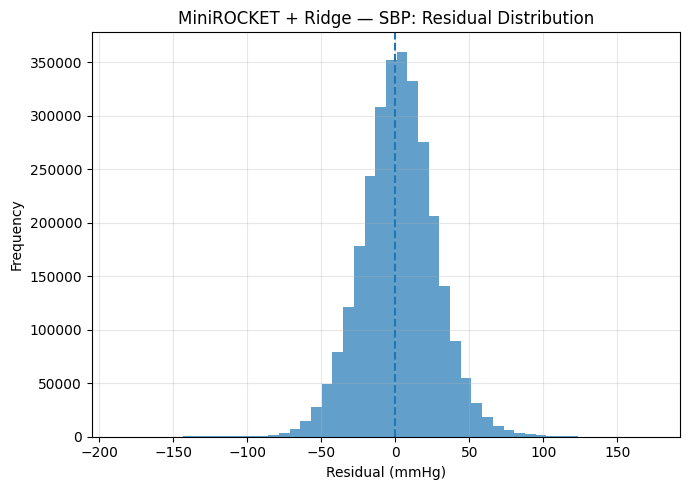

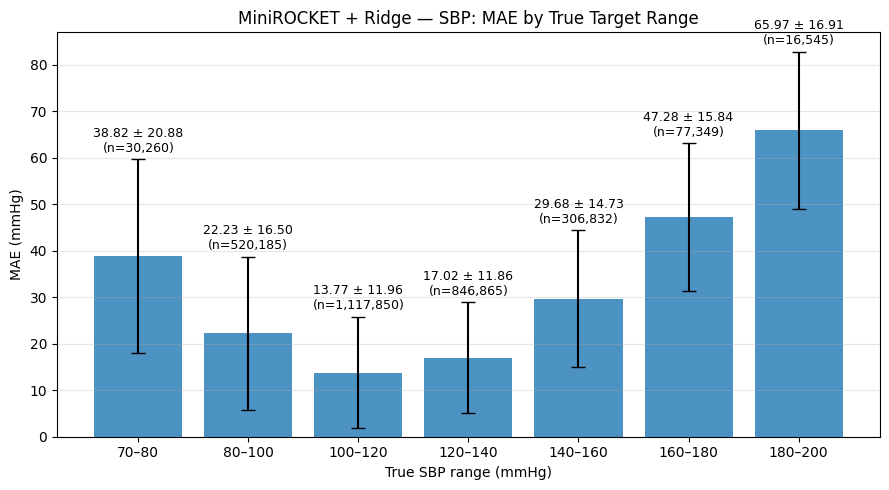

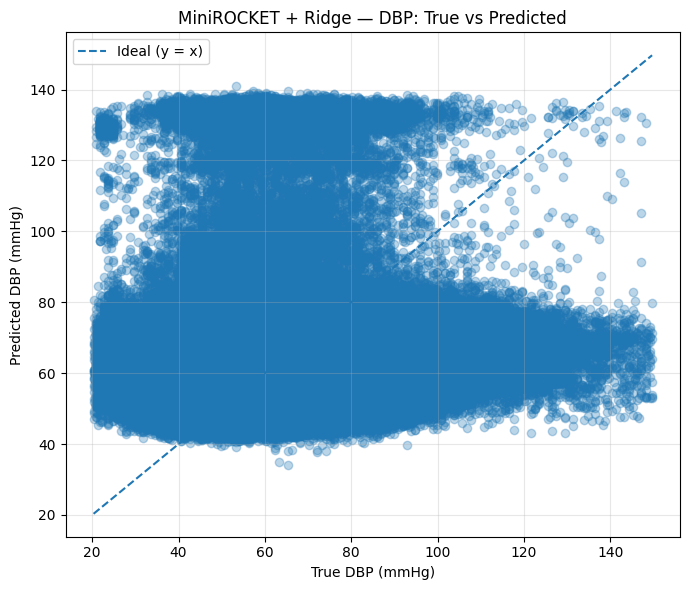

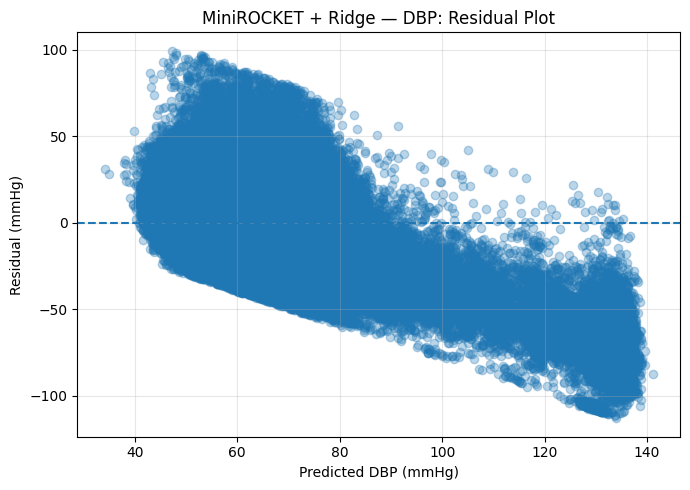

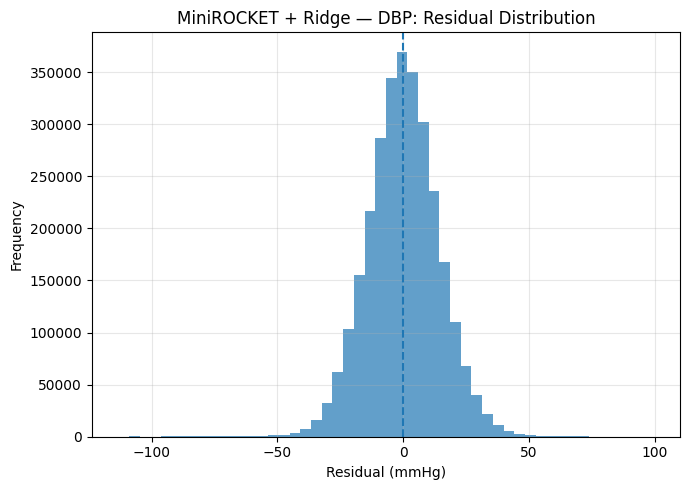

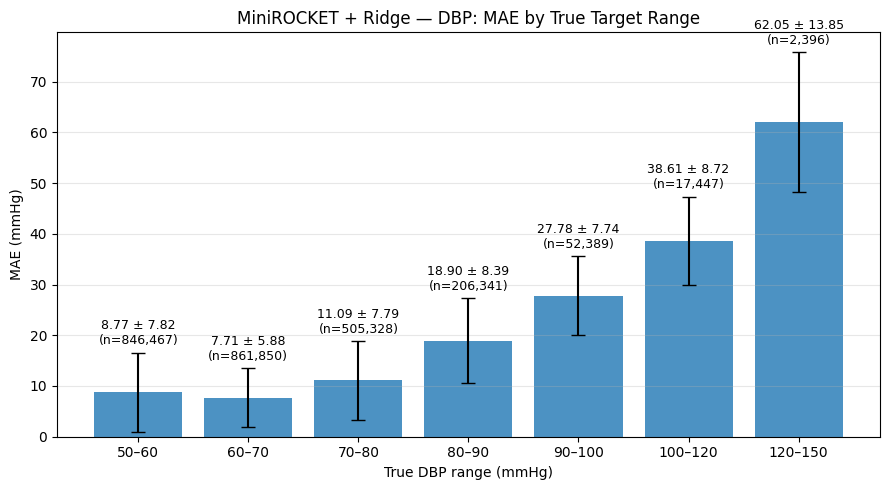


Final prediction shape:
(2928374, 5)

First 5 predictions:
  case_id    SBP_true    SBP_pred   DBP_true   DBP_pred
0  case_1  169.920013  116.034729  77.099091  54.741764
1  case_1  170.907501  111.630493  75.124176  55.204727
2  case_1  169.920013  108.417145  75.124176  51.388306
3  case_1  169.426300  121.344398  75.124176  52.858761
4  case_1  166.957672  124.673996  75.124176  55.131001


In [14]:
results_vitaldb = evaluate_minirocket_vitaldb(
    base_dir=BASE_DIR,
    rocket=rocket,
    best_en_sbp=grid_ridge_sbp,
    best_en_dbp=grid_ridge_dbp,
    model = "Ridge",
    batch_size=5000
)

## MLP ##

In [15]:
mlp_sbp, mlp_dbp = train_mlp(X_train_rocket, y_train, X_val_rocket, y_val)

epoch 00 | TRAIN loss 0.2437 MSE(SBP 268.22, DBP 72.99) RMSE(SBP 16.38, DBP 8.54) | VAL loss 0.2689 MSE(SBP 300.12, DBP 79.28) RMSE(SBP 17.32, DBP 8.90)


epoch 01 | TRAIN loss 0.2179 MSE(SBP 232.45, DBP 66.93) RMSE(SBP 15.25, DBP 8.18) | VAL loss 0.2559 MSE(SBP 282.43, DBP 76.44) RMSE(SBP 16.81, DBP 8.74)


epoch 02 | TRAIN loss 0.1987 MSE(SBP 209.61, DBP 61.11) RMSE(SBP 14.48, DBP 7.82) | VAL loss 0.2441 MSE(SBP 263.01, DBP 73.59) RMSE(SBP 16.22, DBP 8.58)


epoch 03 | TRAIN loss 0.1870 MSE(SBP 196.24, DBP 58.19) RMSE(SBP 14.01, DBP 7.63) | VAL loss 0.2386 MSE(SBP 259.59, DBP 72.34) RMSE(SBP 16.11, DBP 8.51)


epoch 04 | TRAIN loss 0.1755 MSE(SBP 180.89, DBP 54.02) RMSE(SBP 13.45, DBP 7.35) | VAL loss 0.2369 MSE(SBP 250.91, DBP 71.47) RMSE(SBP 15.84, DBP 8.45)


...

epoch 25 | TRAIN loss 0.0965 MSE(SBP 91.21, DBP 31.27) RMSE(SBP 9.55, DBP 5.59) | VAL loss 0.1998 MSE(SBP 205.12, DBP 62.95) RMSE(SBP 14.32, DBP 7.93)


epoch 26 | TRAIN loss 0.0952 MSE(SBP 89.91, DBP 30.87) RMSE(SBP 9.48, DBP 5.56) | VAL loss 0.1988 MSE(SBP 204.82, DBP 61.71) RMSE(SBP 14.31, DBP 7.86)


epoch 27 | TRAIN loss 0.0950 MSE(SBP 89.25, DBP 30.78) RMSE(SBP 9.45, DBP 5.55) | VAL loss 0.2002 MSE(SBP 205.10, DBP 62.39) RMSE(SBP 14.32, DBP 7.90)


epoch 28 | TRAIN loss 0.0936 MSE(SBP 87.96, DBP 30.33) RMSE(SBP 9.38, DBP 5.51) | VAL loss 0.2002 MSE(SBP 206.18, DBP 62.58) RMSE(SBP 14.36, DBP 7.91)


epoch 29 | TRAIN loss 0.0928 MSE(SBP 87.03, DBP 30.21) RMSE(SBP 9.33, DBP 5.50) | VAL loss 0.1983 MSE(SBP 205.06, DBP 61.69) RMSE(SBP 14.32, DBP 7.85)


In [16]:
y_pred_sbp = batch_predict(mlp_sbp, X_test_rocket)
y_pred_dbp = batch_predict(mlp_dbp, X_test_rocket)
print_metrics(y_test[:, 0], y_pred_sbp)
print_metrics(y_test[:, 1], y_pred_dbp)

RMSE: 15.6079
MSE : 243.6064
R²  : 0.5388
MAE : 10.9247
RMSE: 8.1617
MSE : 66.6136
R²  : 0.4668
MAE : 5.4100


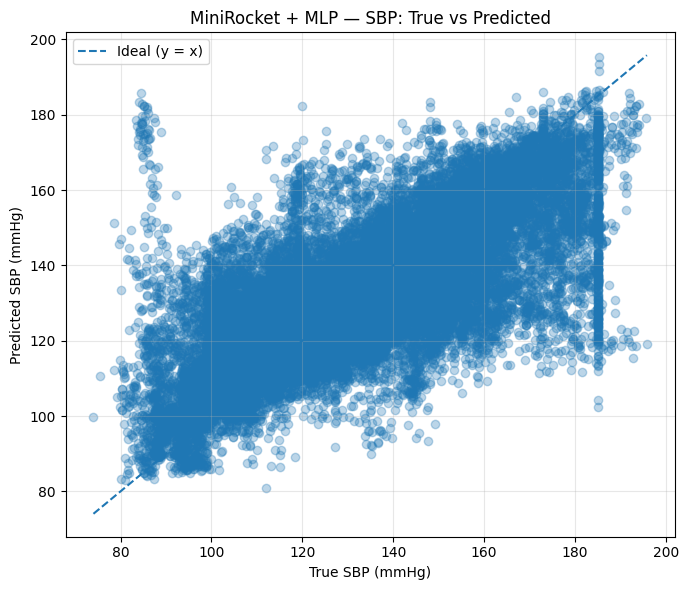

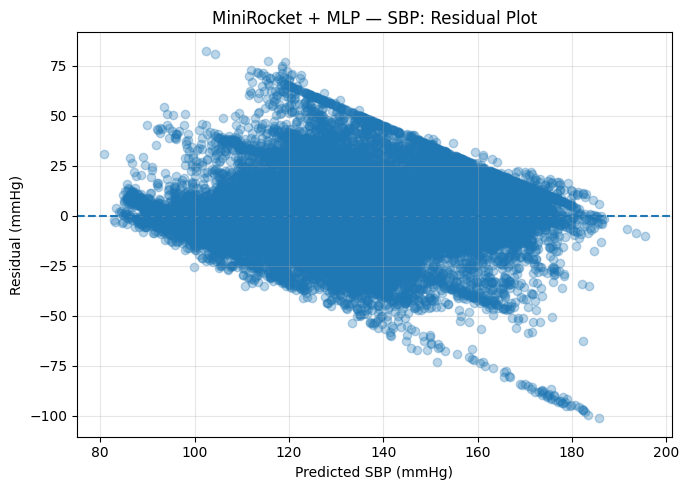

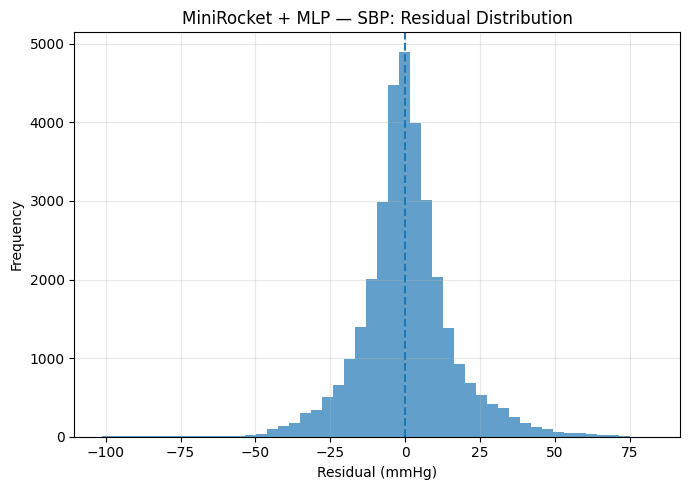

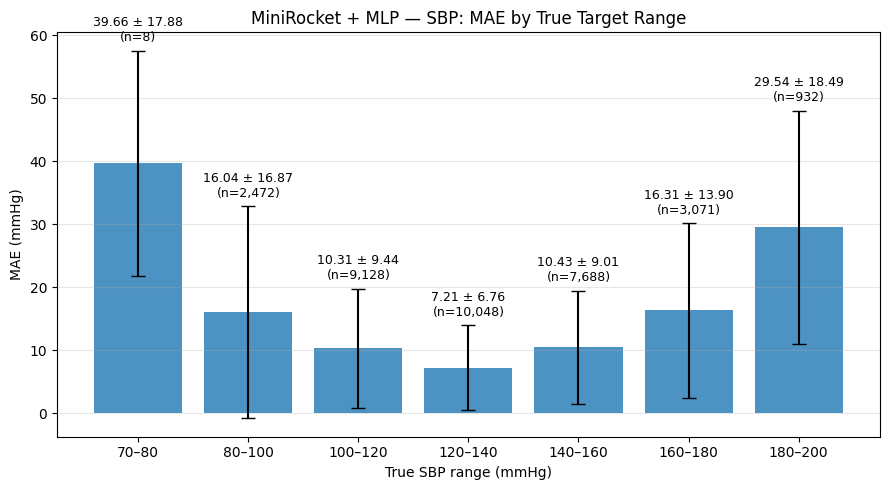

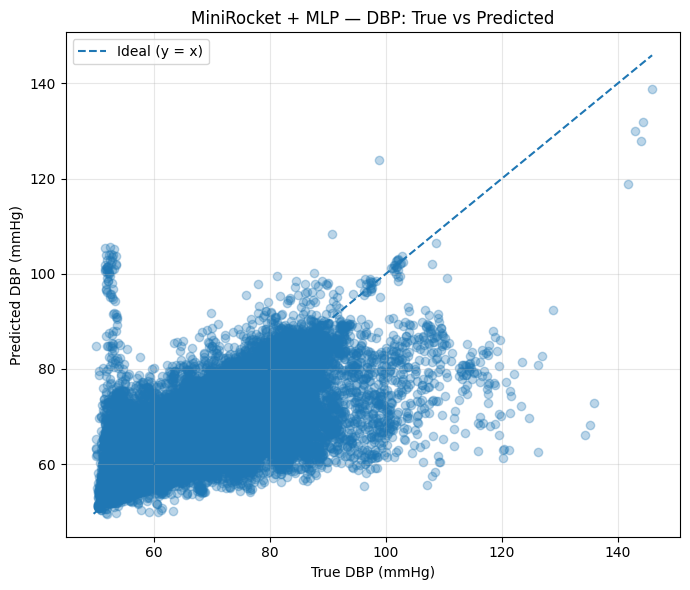

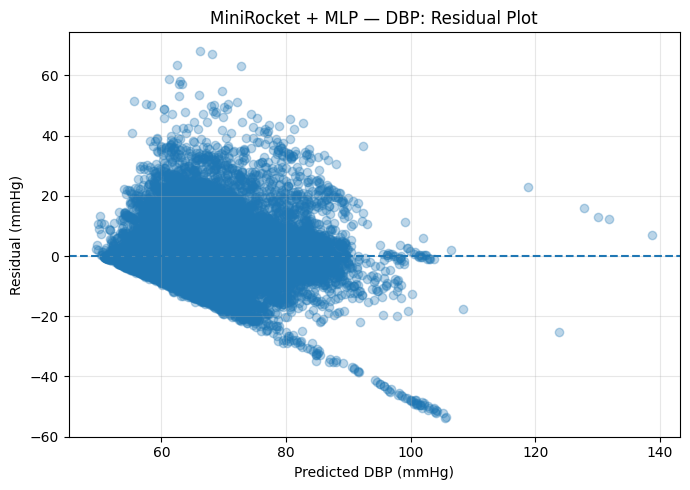

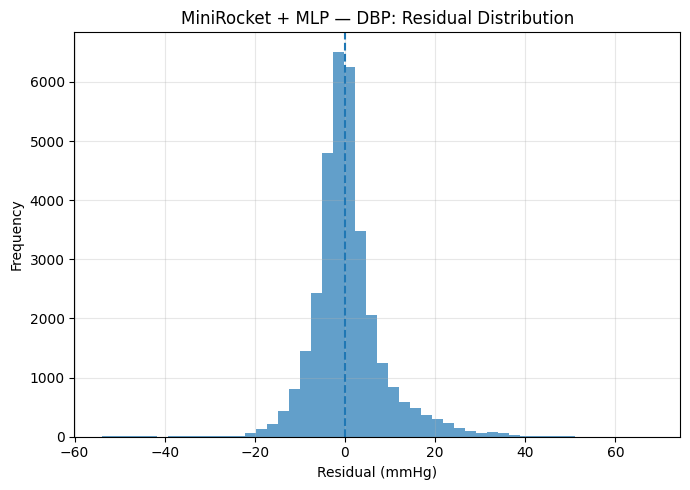

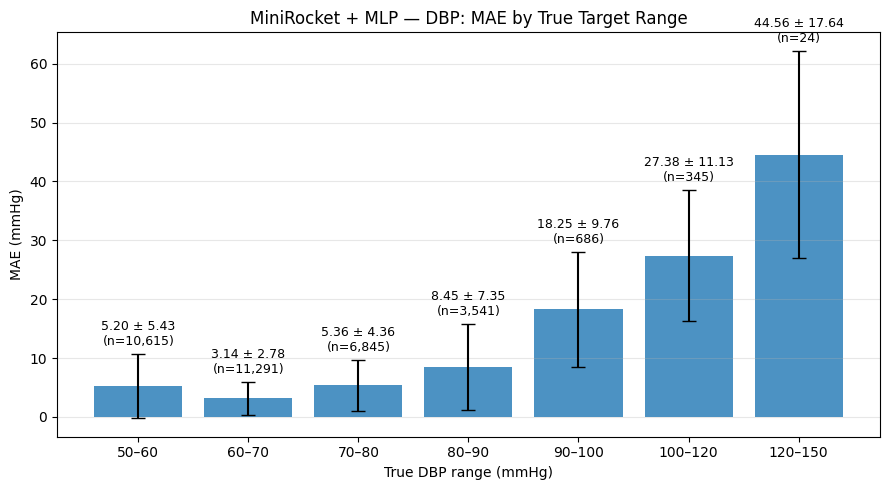

In [17]:
plot_regression_results(
    y_test_sbp,
    y_pred_sbp,
    "MiniRocket + MLP",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_dbp,
    "MiniRocket + MLP",
    "DBP"
)

Number of VitalDB cases: 1968


MiniROCKET VitalDB prediction: 100%|██████████| 1968/1968 [32:33<00:00,  1.01case/s]




MiniROCKET + MLP
VITALDB ZERO-SHOT RESULTS

SBP
------------------------------
RMSE: 23.3018
MSE : 542.9749
R²  : -0.2746
MAE : 18.6764

DBP
------------------------------
RMSE: 12.8152
MSE : 164.2292
R²  : -0.0146
MAE : 10.1336


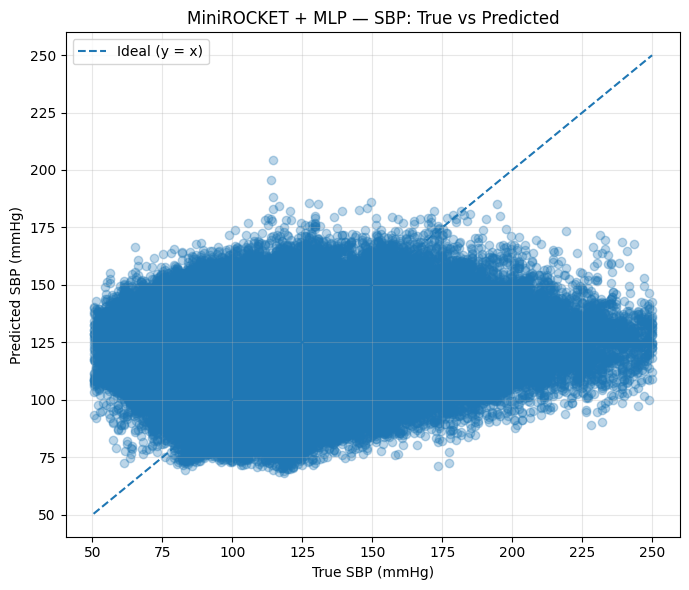

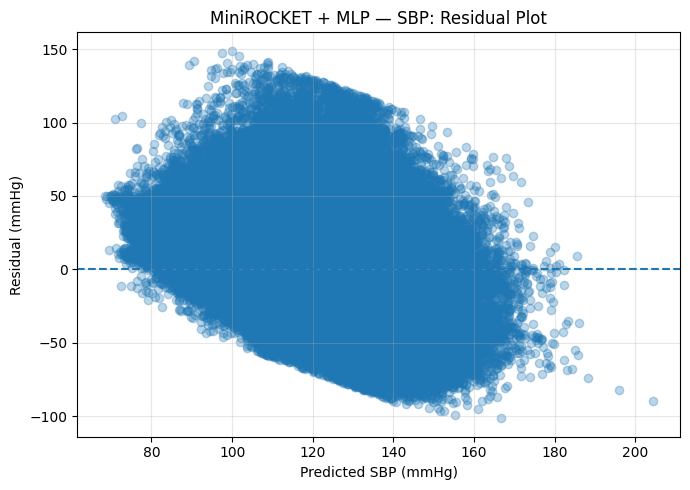

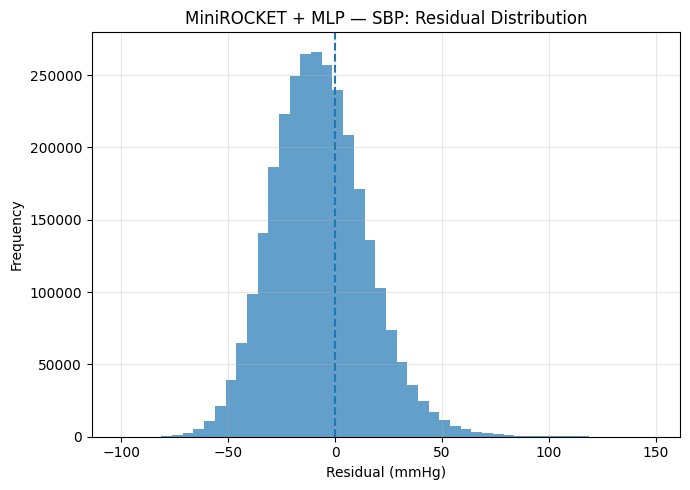

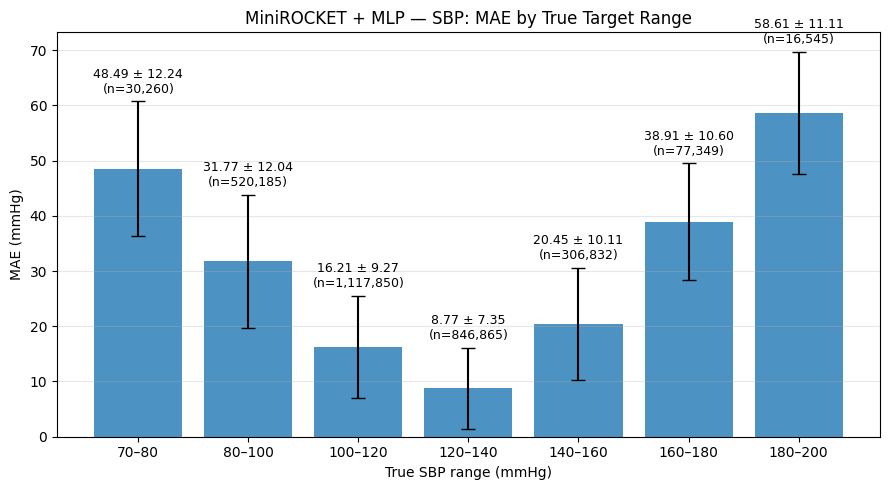

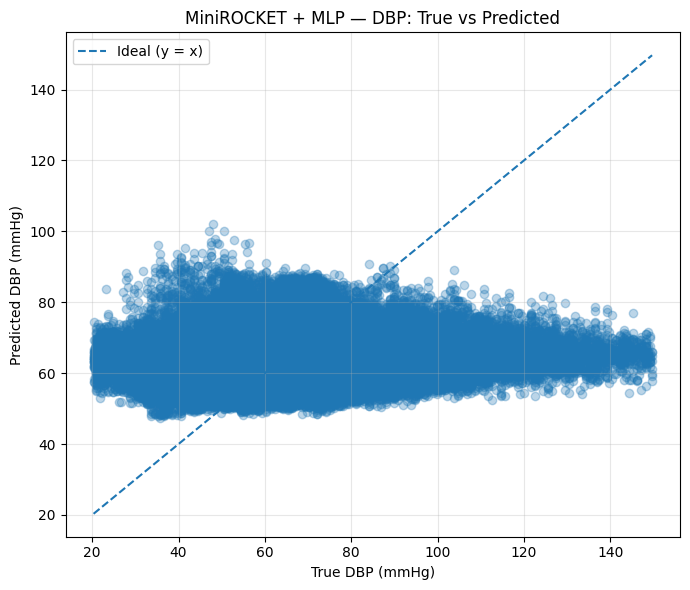

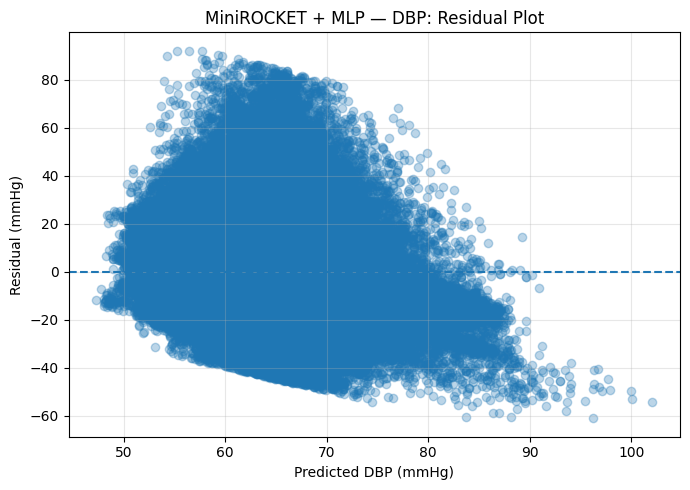

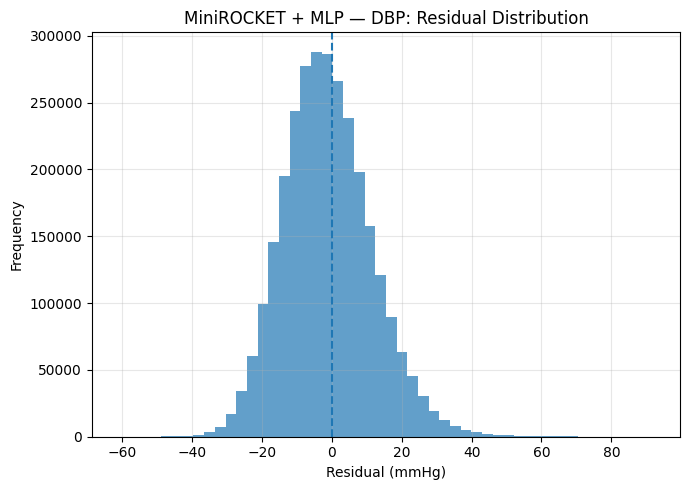

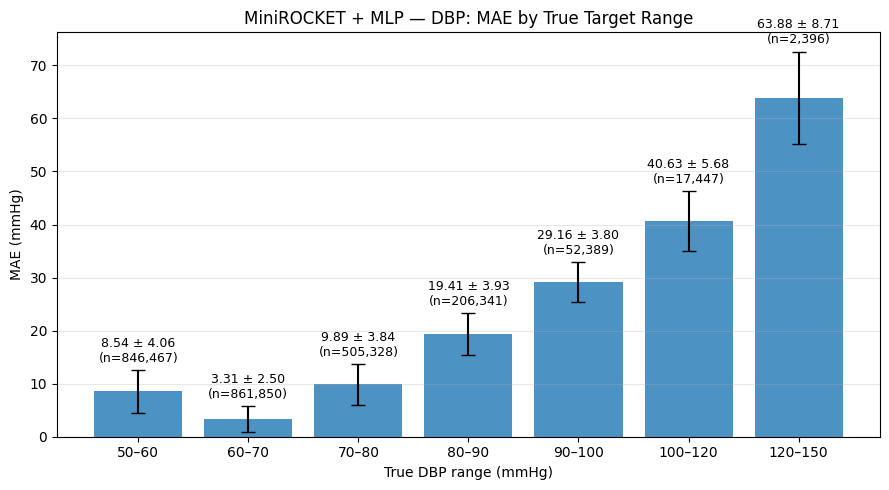


Final prediction shape:
(2928374, 5)

First 5 predictions:
  case_id    SBP_true    SBP_pred   DBP_true   DBP_pred
0  case_1  169.920013  112.944130  77.099091  63.343689
1  case_1  170.907501  110.731140  75.124176  59.762554
2  case_1  169.920013  114.811798  75.124176  60.127914
3  case_1  169.426300  119.307846  75.124176  61.327755
4  case_1  166.957672  120.863800  75.124176  64.124763


In [18]:
results_vitaldb = evaluate_minirocket_vitaldb(
    base_dir=BASE_DIR, rocket=rocket,
    best_en_sbp=mlp_sbp, best_en_dbp=mlp_dbp, model = "MLP", batch_size=2000)

## Feature Selection ##

In [19]:
sbp_idx, sbp_corr = select_top_pearson_features(
    X_train_rocket,
    y_train[:, 0],
    k=1000
)

dbp_idx, dbp_corr = select_top_pearson_features(
    X_train_rocket,
    y_train[:, 1],
    k=1000
)

In [20]:
print("SBP top features:", sbp_idx[:20])
print("SBP correlations:", sbp_corr[:20])

print("DBP top features:", dbp_idx[:20])
print("DBP correlations:", dbp_corr[:20])

SBP top features: [1891  438  233  238 1598 1005 1398  256  514  230  506  272  430  382
 1098  243  540 1729  404  982]
SBP correlations: [ 0.2597494   0.25012895 -0.24969187 -0.24764453  0.24315278 -0.24086642
 -0.23939845 -0.23900488  0.23861027 -0.23701057  0.23673879 -0.2354121
  0.23451713 -0.23388931  0.23284587 -0.23283866  0.2318548   0.2311225
  0.2305989  -0.23041384]
DBP top features: [2102 1720  526  386  555  644 1069  521 1420 1157  383  239  529 1686
  649 1170 1159 1225 2492  416]
DBP correlations: [ 0.22387677  0.2206733   0.21853398 -0.21842538  0.21756032  0.21754445
 -0.2175374   0.21376985 -0.20923452  0.20919763 -0.20862804 -0.20830706
  0.20658146  0.2045549   0.20417526  0.20319755  0.20307377  0.20258221
 -0.20229776  0.20053734]
